### Some algorithms to solve 1D differential equations

Let's solve numerically:

$$
    \frac{d}{dt} \, y(t) = \frac{y(t)}{2} - \left[ t \, y(t) \right]^{2}
$$

With $y(0) = 1$

Reference solution:

$$
    y(t) = \frac{1}{2 \, t^2 - 8 t + 16 - e^{- t / 2}}
$$

In [1]:
import numpy as np
from scipy.optimize import fixed_point # Solves g(x0) = x0
import matplotlib.pyplot as plt

### Euler forward scheme

$$
    y(t_{j + 1}) = y(t_j) + \delta_t \, f(t_j, y(t_j))
$$

In [2]:
def euler_forward(f, t_ini, t_fin, delta_t, y_ini): # Implements the forward Euler method

    N = round((t_fin - t_ini) / delta_t) # Compute total number of steps
    t = np.linspace(t_ini, t_fin, N + 1, endpoint = True) # Time discretization
    y = np.empty(N + 1) # y is the solution array
    y[0] = y_ini # Initial value

    dt = delta_t
    func = f

    for j in range(N): # Euler forward method applied
        y[j + 1] = y[j] + dt * func(t[j], y[j])

    return t, y # Returns time steps and the solution

In [3]:
f = lambda t, y: y / 2.0 - (y * t) ** 2 # Differential equation
g = lambda t: 1.0 / (2.0 * t ** 2 - 8.0 * t + 16.0 - 15.0 * np.exp(- t / 2.0)) # Exact solution

t_ini, t_fin = 0.0, 3.0 # t span = (0, 3)
delta_t = 0.1 # delta_t = 0.1
y_ini = 1.0 # y(0) = 1

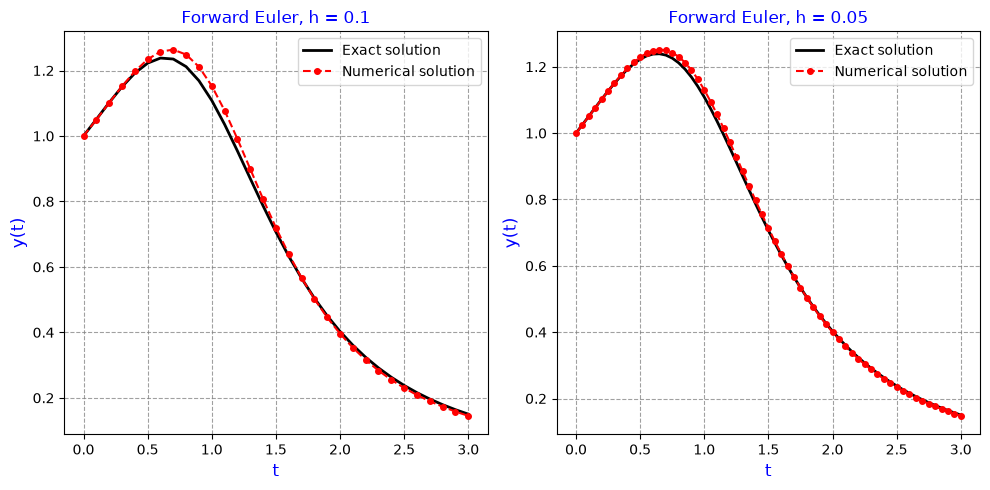

In [4]:
# Compute solutions for two different step sizes
delta_t1 = 0.1
sol1 = euler_forward(f, t_ini, t_fin, delta_t1, y_ini)

delta_t2 = 0.05
sol2 = euler_forward(f, t_ini, t_fin, delta_t2, y_ini)

# Plot section
fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (10, 5))

# Left subplot: delta_t = 0.1
ax1.plot(sol1[0], g(sol1[0]), label = 'Exact solution', color = 'black', linewidth = 2)
ax1.plot(sol1[0], sol1[1], '--o', markersize = 4, label = 'Numerical solution', color = 'red')
ax1.set_title(f'Forward Euler, h = {delta_t1}', fontsize = 12, color = 'blue')
ax1.set_xlabel('t', fontsize = 12, color = 'blue')
ax1.set_ylabel('y(t)', fontsize = 12, color = 'blue')
ax1.grid(True, linestyle = '--', alpha = 0.75, color = 'grey')
ax1.legend(loc = 'best')

# Right subplot: delta_t = 0.05
ax2.plot(sol2[0], g(sol2[0]), label = 'Exact solution', color = 'black', linewidth = 2)
ax2.plot(sol2[0], sol2[1], '--o', markersize = 4, label = 'Numerical solution', color = 'red')
ax2.set_title(f'Forward Euler, h = {delta_t2}', fontsize = 12, color = 'blue')
ax2.set_xlabel('t', fontsize = 12, color = 'blue')
ax2.set_ylabel('y(t)', fontsize = 12, color = 'blue')
ax2.grid(True, linestyle = '--', alpha = 0.75, color = 'grey')
ax2.legend(loc = 'best')

plt.tight_layout()
plt.show()

### Backward Euler scheme

$$
    y(t_{j + 1}) - y(t_j) - \delta_t \, f(t_{j + 1}, y_{j + 1}) = 0
$$

In [5]:
def euler_backward(f, t_ini, t_fin, delta_t, y_ini): # Implements the backward Euler method

    N = round((t_fin - t_ini) / delta_t)
    t = np.linspace(t_ini, t_fin, N + 1, endpoint = True)
    y = np.empty(N + 1)
    y[0] = y_ini
    dt = delta_t

    implicit_equation = lambda y_new, y_old, t_new: 2.0 * y_new - y_old - dt * f(t_new, y_new) # Implicit equation: y_new - y_old - dt * f(t_new, y_new) = 0

    for j in range(N):

        t_new = t[j + 1]
        y_old = y[j]

        y_guess = y_old # Initial guess: use y_old
        y_new = fixed_point( # Using fixed_point from scipy
            func = implicit_equation,
            x0 = y_guess,
            args = (y_old, t_new),
            xtol = 1e-06
        )

        y[j + 1] = y_new

    return t, y

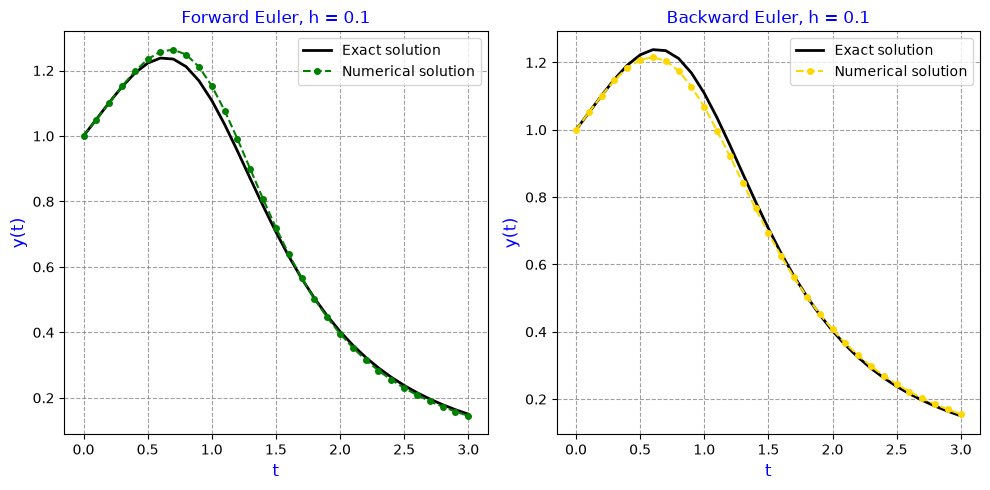

In [6]:
# Compute solutions for two different methods
delta_t = 0.1 # delta_t = 0.1 for both methods

sol1 = euler_forward(f, t_ini, t_fin, delta_t, y_ini) # Forward method
sol2 = euler_backward(f, t_ini, t_fin, delta_t, y_ini) # Backward method

# Plot section
fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (10, 5))

# Left subplot: delta_t = 0.1 Forward
ax1.plot(sol1[0], g(sol1[0]), label = 'Exact solution', color = 'black', linewidth = 2)
ax1.plot(sol1[0], sol1[1], '--o', markersize = 4, label = 'Numerical solution', color = 'green')
ax1.set_title(f'Forward Euler, h = {delta_t}', fontsize = 12, color = 'blue')
ax1.set_xlabel('t', fontsize = 12, color = 'blue')
ax1.set_ylabel('y(t)', fontsize = 12, color = 'blue')
ax1.grid(True, linestyle = '--', alpha = 0.75, color = 'grey')
ax1.legend(loc = 'best')

# Right subplot: delta_t = 0.1 Backward
ax2.plot(sol2[0], g(sol2[0]), label = 'Exact solution', color = 'black', linewidth = 2)
ax2.plot(sol2[0], sol2[1], '--o', markersize = 4, label = 'Numerical solution', color = 'gold')
ax2.set_title(f'Backward Euler, h = {delta_t}', fontsize = 12, color = 'blue')
ax2.set_xlabel('t', fontsize = 12, color = 'blue')
ax2.set_ylabel('y(t)', fontsize = 12, color = 'blue')
ax2.grid(True, linestyle = '--', alpha = 0.75, color = 'grey')
ax2.legend(loc = 'best')

plt.tight_layout()
plt.show()

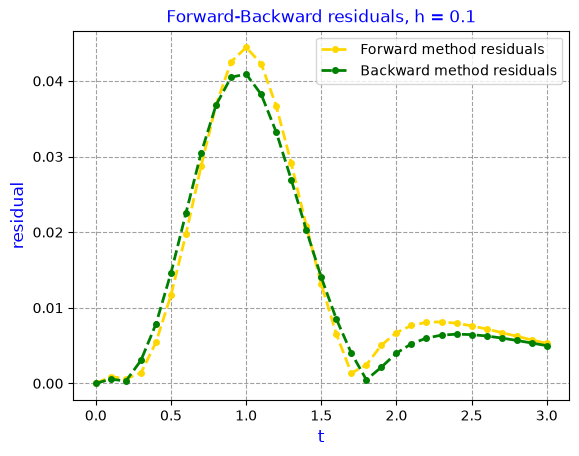

In [7]:
# Plotting residuals
plt.plot(sol1[0], np.abs(g(sol1[0]) - sol1[1]), '--o', label = 'Forward method residuals', color = 'gold', linewidth = 2, markersize = 4)
plt.plot(sol2[0], np.abs(g(sol2[0]) - sol2[1]), '--o', label = 'Backward method residuals', color = 'green', linewidth = 2, markersize = 4)
plt.title(f'Forward-Backward residuals, h = {delta_t}', fontsize = 12, color = 'blue')
plt.xlabel('t', fontsize = 12, color = 'blue')
plt.ylabel('residual', fontsize = 12, color = 'blue')
plt.grid(True, linestyle = '--', alpha = 0.75, color = 'grey')
plt.legend(loc = 'best')
plt.show()

### Crank–Nicolson scheme

$$
    y_{j + 1} - y_{j} - \frac{\delta_t}{2} \, \left[ f(t_{j + 1}, \, y_{j + 1}) + f(t_j, \, y_j) \right] = 0
$$

In [8]:
def CN(f, t_ini, t_fin, delta_t, y_ini): # Implements the Crank–Nicolson method

    N = round((t_fin - t_ini) / delta_t)
    t = np.linspace(t_ini, t_fin, N + 1, endpoint = True)
    y = np.empty(N + 1)
    y[0] = y_ini
    dt = delta_t

    implicit_equation = lambda y_new, y_old, t_new, t_old: 2.0 * y_new - y_old - dt / 2.0 * (f(t_new, y_new) + f(t_old, y_old)) # Implicit equation: y_new - y_old - dt / 2 * [f(t_new, y_new) + f(t_old, y_old)] = 0

    for j in range(N):

        t_old = t[j]
        t_new = t[j + 1]
        y_old = y[j]

        y_guess = y_old # Initial guess: use y_old
        y_new = fixed_point( # Using fixed_point from scipy
            func = implicit_equation,
            x0 = y_guess,
            args = (y_old, t_new, t_old),
            xtol = 1e-06
        )
        y[j + 1] = y_new

    return t, y

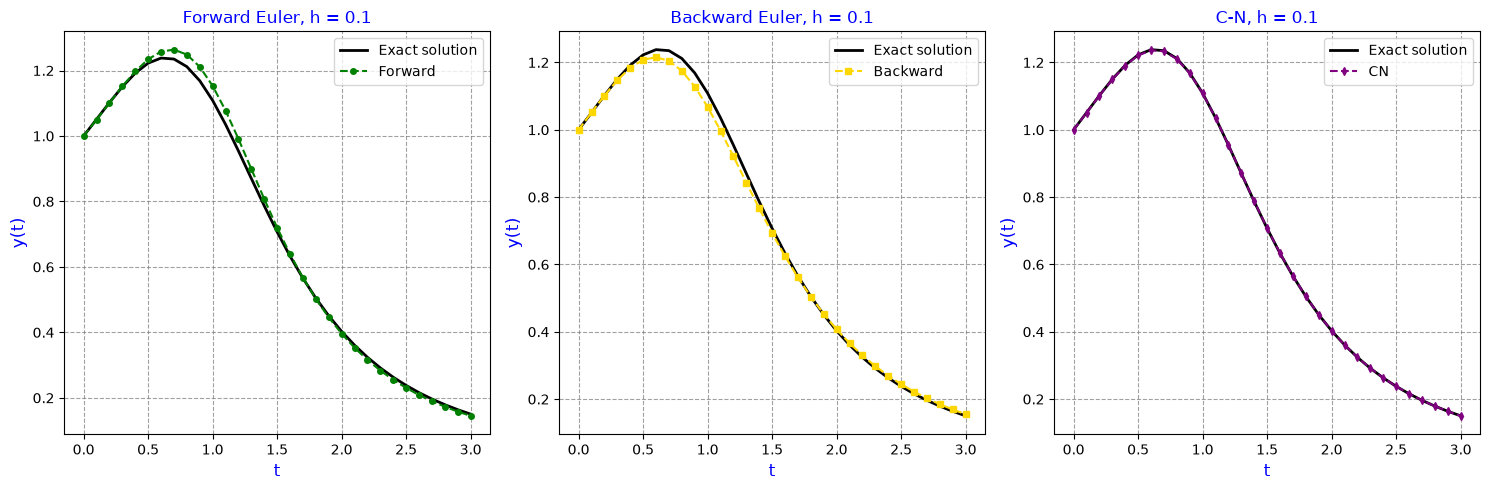

In [9]:
# Plotting solutions using all methods with delta_t = 0.1
sol1 = euler_forward(f, t_ini, t_fin, delta_t, y_ini) # Forward
sol2 = euler_backward(f, t_ini, t_fin, delta_t, y_ini) # Backward
sol3 = CN(f, t_ini, t_fin, delta_t, y_ini) # CN

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize = (15, 5))

t_grid = sol1[0]
y_exact = g(t_grid)

# Left: Forward Euler
ax1.plot(t_grid, y_exact, label = 'Exact solution', color = 'black', linewidth = 2)
ax1.plot(sol1[0], sol1[1], '--o', markersize = 4, label ='Forward', color ='green')
ax1.set_title(f'Forward Euler, h = {delta_t}', fontsize = 12, color = 'blue')
ax1.set_xlabel('t', fontsize = 12, color = 'blue')
ax1.set_ylabel('y(t)', fontsize = 12, color = 'blue')
ax1.grid(True, linestyle = '--', alpha = 0.75, color = 'grey')
ax1.legend(loc = 'best')

# Middle: Backward Euler
ax2.plot(t_grid, y_exact, label = 'Exact solution', color = 'black', linewidth = 2)
ax2.plot(sol2[0], sol2[1], '--s', markersize = 4, label = 'Backward', color = 'gold')
ax2.set_title(f'Backward Euler, h = {delta_t}', fontsize = 12, color = 'blue')
ax2.set_xlabel('t', fontsize = 12, color = 'blue')
ax2.set_ylabel('y(t)', fontsize = 12, color = 'blue')
ax2.grid(True, linestyle = '--', alpha = 0.75, color = 'grey')
ax2.legend(loc = 'best')

# Right: CN Scheme
ax3.plot(t_grid, y_exact, label = 'Exact solution', color = 'black', linewidth = 2)
ax3.plot(sol3[0], sol3[1], '--d', markersize = 4, label = 'CN', color = 'purple')
ax3.set_title(f'C-N, h = {delta_t}', fontsize = 12, color = 'blue')
ax3.set_xlabel('t', fontsize = 12, color = 'blue')
ax3.set_ylabel('y(t)', fontsize = 12, color = 'blue')
ax3.grid(True, linestyle = '--', alpha = 0.75, color = 'grey')
ax3.legend(loc = 'best')

plt.tight_layout()
plt.show()

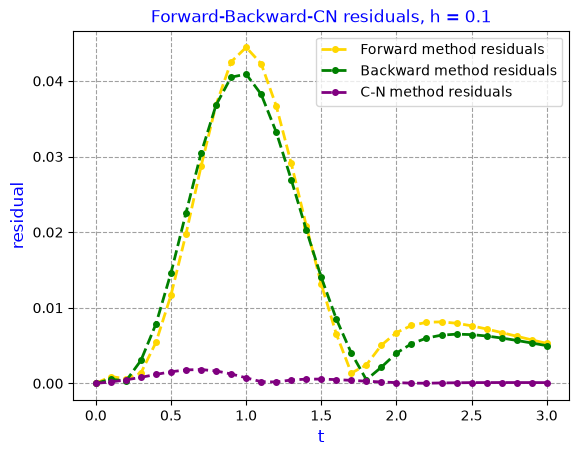

In [10]:
# Plotting residuals
plt.plot(sol1[0], np.abs(g(sol1[0]) - sol1[1]), '--o', label = 'Forward method residuals', color = 'gold', linewidth = 2, markersize = 4)
plt.plot(sol2[0], np.abs(g(sol2[0]) - sol2[1]), '--o', label = 'Backward method residuals', color = 'green', linewidth = 2, markersize = 4)
plt.plot(sol3[0], np.abs(g(sol3[0]) - sol3[1]), '--o', label = 'C-N method residuals', color = 'purple', linewidth = 2, markersize = 4)
plt.title(f'Forward-Backward-CN residuals, h = {delta_t}', fontsize = 12, color = 'blue')
plt.xlabel('t', fontsize = 12, color = 'blue')
plt.ylabel('residual', fontsize = 12, color = 'blue')
plt.grid(True, linestyle = '--', alpha = 0.75, color = 'grey')
plt.legend(loc = 'best')
plt.show()